<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Gaussian Mixture Models**

## **Introduction**

**Gaussian Mixture Models (GMM)** are a probabilistic clustering method used to group similar data points together. Unlike K-Means, which assigns each point to exactly one cluster, GMM estimates the probability that a data point belongs to each cluster.

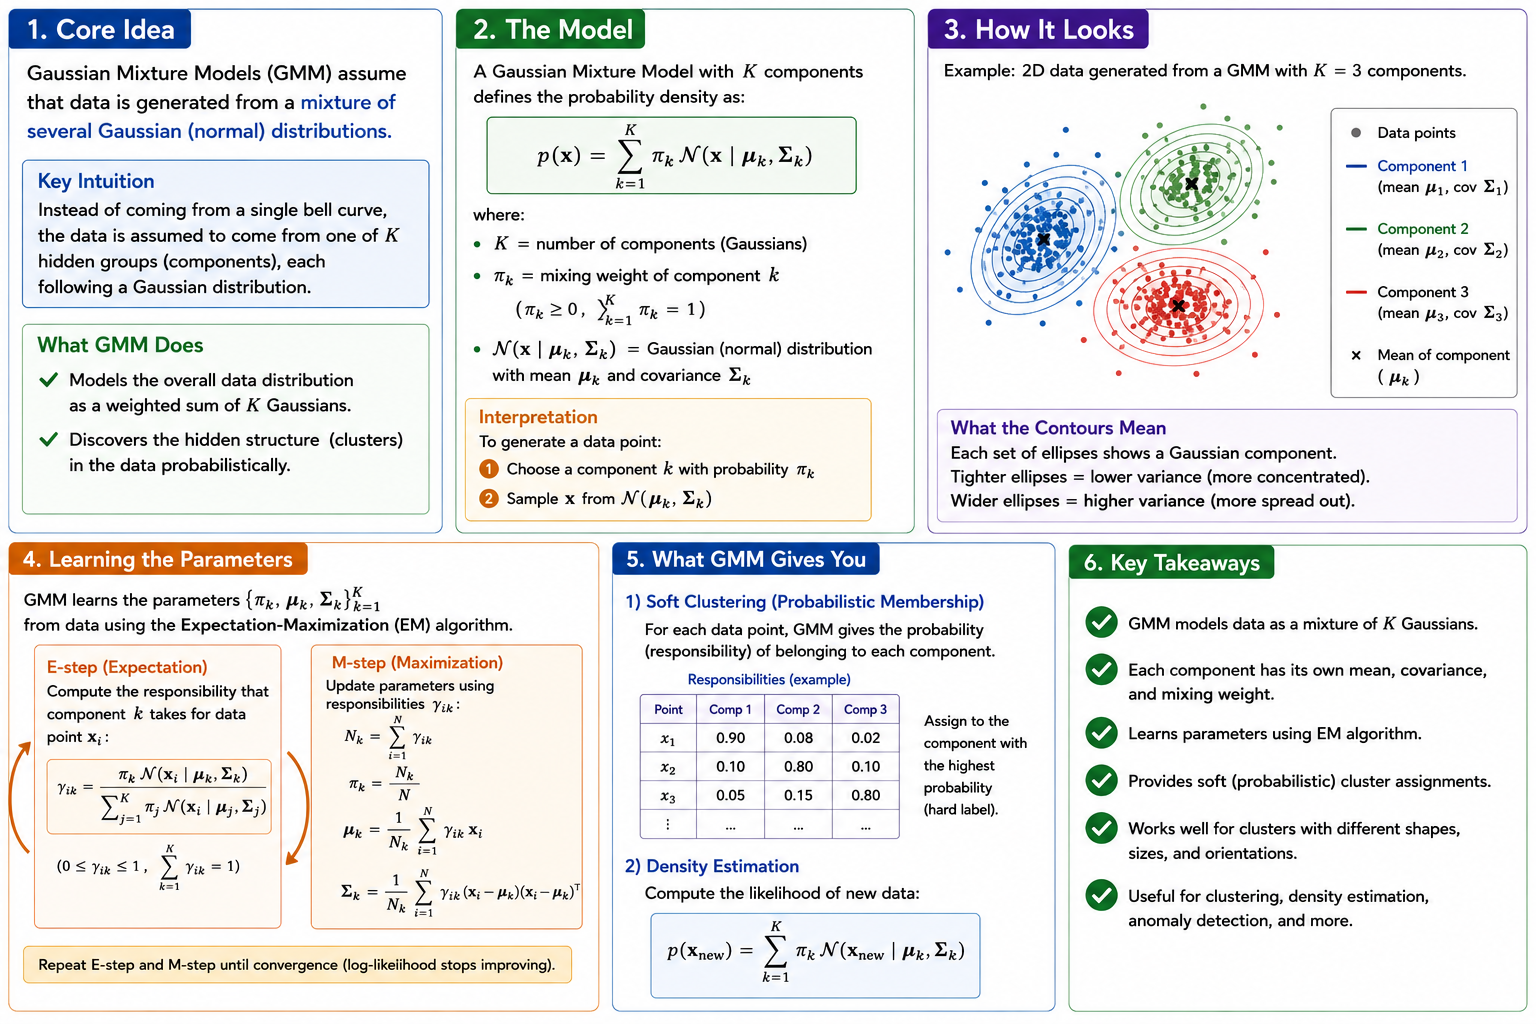


## **Use cases of GMM:**

Gaussian Mixture Models are commonly used in:

- **Recommender systems** – grouping users with similar preferences, such as movie viewing behavior.
- **Customer segmentation** – separating customers into groups for targeted marketing.
- **Anomaly detection** – identifying unusual data points that differ from normal patterns.
- **Image segmentation** – grouping pixels with similar colors or intensities.
- **Speech and signal processing** – modeling complex sound patterns.


## **When is GMM better than K-Means?**

K-Means performs **hard clustering**, meaning each data point belongs to only one cluster.

For example:

- A customer is assigned completely to Cluster A or Cluster B.
- No uncertainty information is provided.

GMM performs **soft clustering**, meaning each data point has a probability of belonging to different clusters. This is useful when clusters overlap.

Imagine a car recommendation system:

- Cluster A customers are more likely to buy a luxury car.
- Cluster B customers are more likely to buy a budget car.

With **K-Means**, a customer is forced into one cluster.

With **GMM**, the model may predict for a customer:

- 90% probability of belonging to Cluster A
- 10% probability of belonging to Cluster B

This makes GMM more flexible than K-Means, especially when clusters overlap. This probability information can help businesses make better decisions.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/images/car.png" style="width: 60%">


### **Workflow**
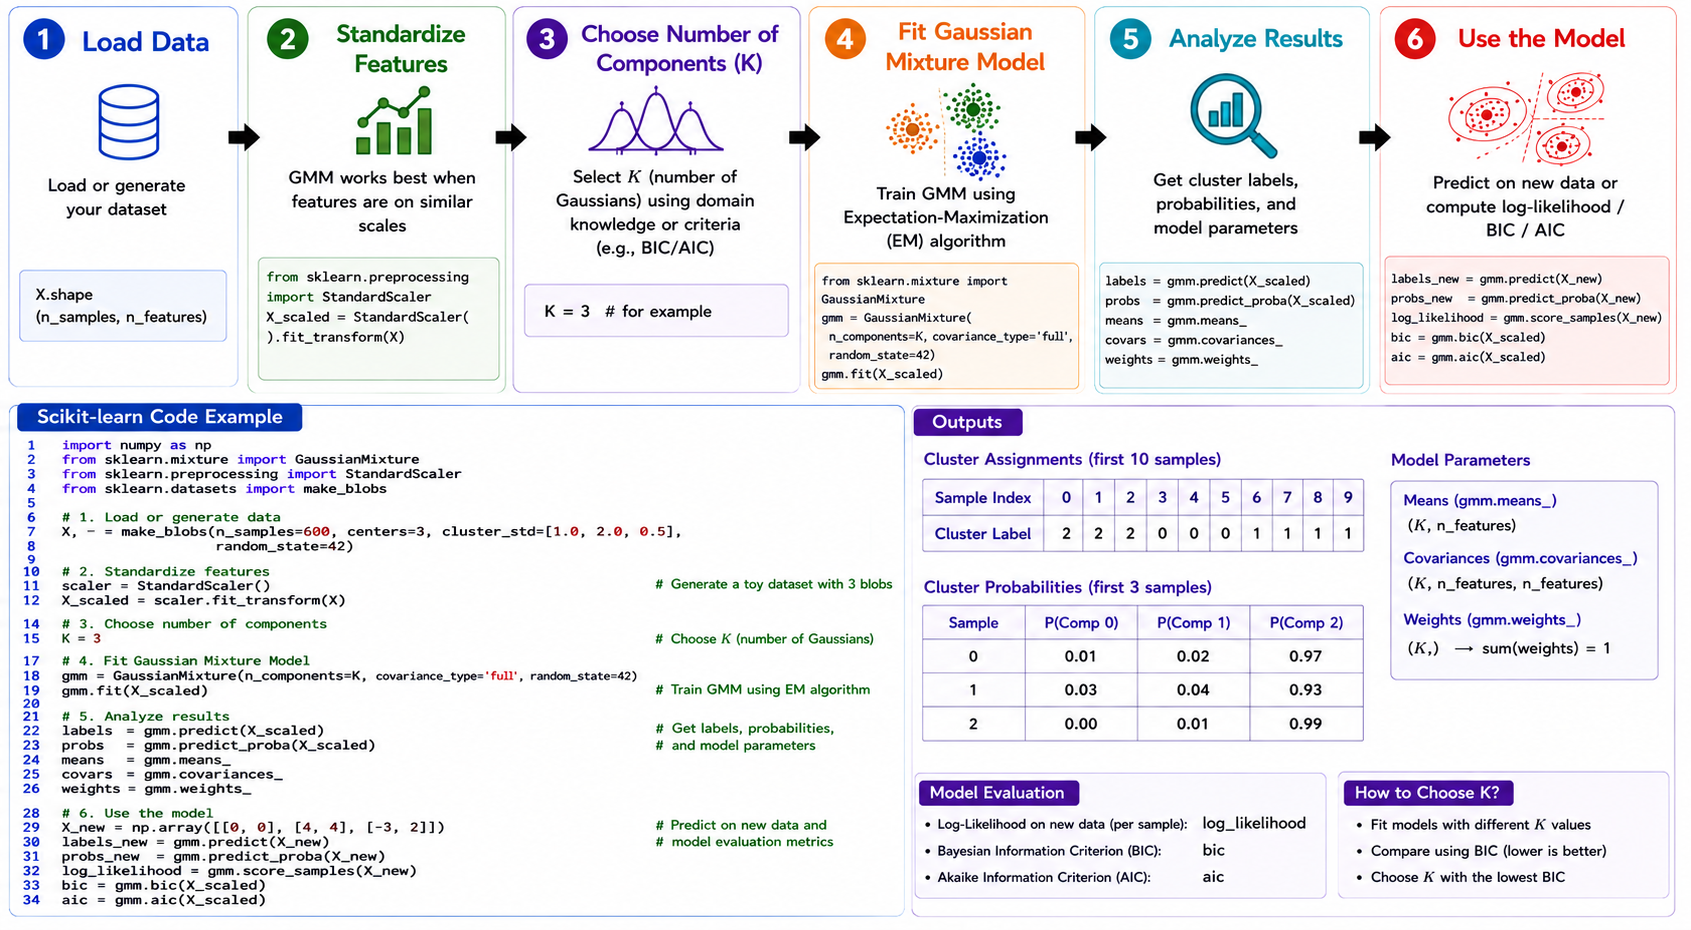

## __Table of Contents__

1. [Objectives](<#Objectives>)
2. [Setup](<#Setup>)
    1. [Installing Required Libraries](<#Installing-Required-Libraries>)
    2. [Importing Required Libraries](<#Importing-Required-Libraries>)
    3. [Defining Helper Functions](<#Defining-Helper-Functions>)
3. [What are Gaussian Mixture Models (GMM)?](<#What-are-Gaussian-Mixture-Models-(GMM)?>)
    1. [Gaussian Distribution](<#Gaussian-Distribution>)
    2. [Gaussian Mixture](<#Gaussian-Mixture>)
    3. [GMM vs K-Means](<#GMM-vs-K-Means>)
    4. [Playing around with means, standard deviations, and weights](<#Playing-around-with-means,-standard-deviations,-and-weights>)
    5. [Introducing sklearn.mixture.GaussianMixture](<#Introducing-sklearn.mixture.GaussianMixture>)
    6. [GMM.predict_proba](<#GMM.predict_proba>)
4. [Example 1: Applying GMM on a 2d dataset](<#Example-1:-Applying-GMM-on-a-2d-dataset>)
    1. [Generate an artificial 2d Gaussian mixture data](<#Generate-an-artificial-2d-Gaussian-mixture-data>)
    2. [Fit a GMM](<#Fit-a-GMM>)
    3. [Plot the clusters](<#Plot-the-clusters>)
    4. [Try different values of Covariance_type](<#Try-different-values-of-Covariance_type>)
5. [Example 2: Applying GMM on real world data - Image Segmentation](<#Example-2:-Applying-GMM-on-real-world-data---Image-Segmentation>)
6. [Exercises](<#Exercises>)
    1. [Exercise 1 - Scale the data (using StandardScaler)](<#Exercise-1---Scale-the-data-(using-StandardScaler)>)
    2. [Exercise 2 - Use PCA with n_components = 2 for dimension reduction](<#Exercise-2---Use-PCA-with-n_components-=-2-for-dimension-reduction>)
    3. [Exercise 3 - Fit a GMM to the reduced data](<#Exercise-3---Fit-a-GMM-to-the-reduced-data>)
    4. [Exercise 4 - Output the predicted labels for visualizing clusters](<#Exercise-4---Output-the-predicted-labels-for-visualizing-clusters>)
    5. [Exercise 5 - Clustering and visualizing using 3 principal components (OPTIONAL)](<#Exercise-5---Clustering-and-visualizing-using-3-principal-components-(OPTIONAL)>)


## **Objectives**
In this lab, you will be applying clustering analysis on multivariate datasets using **Gaussian Mixture Models** (GMM).

After completing this lab you will be able to:

- __Understand__ what Gaussian mixture is and how its distribution parameters affect the prior probabilities.
- __Understand__ what Gaussian mixture model is and how it works as a clustering technique.
- __Apply__ GMM effectively.

The goal is to understand how probabilistic clustering works and why GMM can model complex datasets better than K-Means in many situations.


----


## **Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Installing Required Libraries

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [16]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1 wget
# Note: If your environment doesn't support "!mamba install", use "!pip install pandas==1.3.4 ..."

The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


### **Importing Required Libraries**

_We recommend you import all required libraries in one place (here):_


In [17]:
# You can also use this section to suppress warnings generated by your code:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.mixture import GaussianMixture
import seaborn as sns
from urllib.request import urlopen
from PIL import Image
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
from itertools import chain
from matplotlib.patches import Ellipse


sns.set_context('notebook')
sns.set_style('white')

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

### Defining Helper Functions

_Use this section to define any helper functions to help the notebook's code readability:_


In [18]:
# This function will allow us to easily plot data taking in x values, y values, and a title
def plot_univariate_mixture(means, stds, weights, N=10000, seed=10):
    """
    returns the simulated 1d dataset X, a figure, and the figure's ax

    """
    np.random.seed(seed)
    if not len(means) == len(stds) == len(weights):
        raise Exception("Length of mean, std, and weights don't match.")
    K = len(means)

    mixture_idx = np.random.choice(K, size=N, replace=True, p=weights)
    # generate N possible values of the mixture
    X = np.fromiter(
        (ss.norm.rvs(loc=means[i], scale=stds[i]) for i in mixture_idx),
        dtype=np.float64,
    )

    # generate values on the x axis of the plot
    xs = np.linspace(X.min(), X.max(), 300)
    ps = np.zeros_like(xs)

    for mu, s, w in zip(means, stds, weights):
        ps += ss.norm.pdf(xs, loc=mu, scale=s) * w

    fig, ax = plt.subplots()
    ax.plot(xs, ps, label="pdf of the Gaussian mixture")
    ax.set_xlabel("X", fontsize=15)
    ax.set_ylabel("P", fontsize=15)
    ax.set_title("Univariate Gaussian mixture", fontsize=15)
    # plt.show()

    return X.reshape(-1, 1), fig, ax


def plot_bivariate_mixture(means, covs, weights, N=10000, seed=10):
    """
    returns the simulated 2d dataset X and a scatter plot is shown

    """
    np.random.seed(seed)
    if not len(mean) == len(covs) == len(weights):
        raise Exception("Length of mean, std, and weights don't match.")
    K = len(means)
    M = len(means[0])

    mixture_idx = np.random.choice(K, size=N, replace=True, p=weights)

    # generate N possible values of the mixture
    X = np.fromiter(
        chain.from_iterable(
            multivariate_normal.rvs(mean=means[i], cov=covs[i])
            for i in mixture_idx
        ),
        dtype=float,
    )
    X.shape = N, M

    xs1 = X[:, 0]
    xs2 = X[:, 1]

    plt.scatter(xs1, xs2, label="data")

    L = len(means)
    for l, pair in enumerate(means):
        plt.scatter(pair[0], pair[1], color="red")
        if l == L - 1:
            break
    plt.scatter(pair[0], pair[1], color="red", label="mean")

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title("Scatter plot of the bivariate Gaussian mixture")
    plt.legend()
    plt.show()

    return X


def draw_ellipse(position, covariance, ax=None, **kwargs):
    """
    Draw an ellipse with a given position and covariance

    """
    ax = ax or plt.gca()

    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(
            Ellipse(
                position, nsig * width, nsig * height, angle=angle, **kwargs
            )
        )


def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap="viridis", zorder=2)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    ax.axis("equal")

    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, ax=ax, alpha=w * w_factor)

## **What are Gaussian Mixture Models (GMM)?**

Put simply, Gaussian Mixture Models (GMM) is a clustering algorithm that:

- Fits a weighted combination of Gaussian distributions to your data
- The data scientist (you) needs to determine the number of gaussian distributions (`k`)


<p style='color: blue'>Hard vs Soft Clustering:</p>

- __Hard clustering__ algorithms assign each data point to exactly one cluster.
- __Soft clustering__ algorithms return probabilities of each data point belonging to all `k` clusters

_GMM is a soft clustering algorithm._


### **Gaussian Distribution**

A Gaussian distribution, also called a **normal distribution**, is a bell-shaped probability distribution.

It is defined by:

- **Mean (μ)** – the center of the distribution
- **Standard deviation (σ)** – the spread of the data

The Gaussian probability density function is:

$$ \mathcal{N}(x; \mu, \sigma^2) =
\frac{1}{\sqrt{2\pi\sigma^2}}
e^{-\frac{(x-\mu)^2}{2\sigma^2}} $$

Where:

- x = data point
- μ = mean
- σ² = variance

### **Gaussian Mixture**

A Gaussian Mixture Model assumes the data is generated from multiple Gaussian distributions combined together.

Each cluster has:

- Its own mean
- Its own variance
- A weight representing how large the cluster is

The overall model is:

$$ p(x) =
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x \mid \mu_k, \Sigma_k)$$

Where:

- $K$ = number of clusters
- $\pi_k$ = weight of cluster $k$
- $\mu_k$ = mean of cluster $k$
- $\Sigma_k$ = covariance matrix of cluster $k$

The weights satisfy:

$$
\sum_{k=1}^{K} \pi_k = 1
$$


### **GMM vs K-Means**

| Feature | K-Means | GMM |
|---|---|---|
| Clustering type | Hard clustering | Soft clustering |
| Output | One cluster label | Cluster probabilities |
| Cluster shape | Mostly spherical | Flexible shapes |
| Handles overlap well | No | Yes |
| Complexity | Simple and fast | More computationally expensive |

### **Playing around with means, standard deviations, and weights**

This section helps you understand how a Gaussian mixture is formed by combining multiple Gaussian distributions. The mean controls the peak position, the standard deviation controls the width, and the weight controls each distribution’s contribution to the final curve.

- means equal to **2, 5, 8** respectively
- std equal to **0.2, 0.5, 0.8** respectively
- component weight equal to **0.3, 0.3, 0.4** respectively


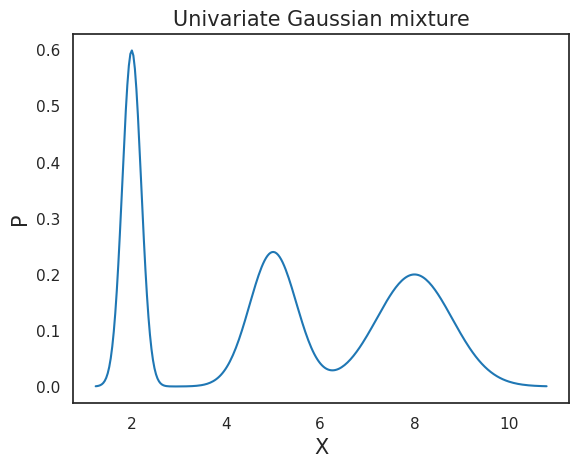

In [19]:
X1, fig1, ax1 = plot_univariate_mixture(
    means=[2, 5, 8], stds=[0.2, 0.5, 0.8], weights=[0.3, 0.3, 0.4]
)

The peaks in the probability density function (pdf) plot are located around $x = 2$, $5$, and $8$, which correspond to the means of the three Gaussian distributions.


If we increase the value of the standard deviations, we will see the bell shapes become wider and there will be overlaps between two Gaussians.


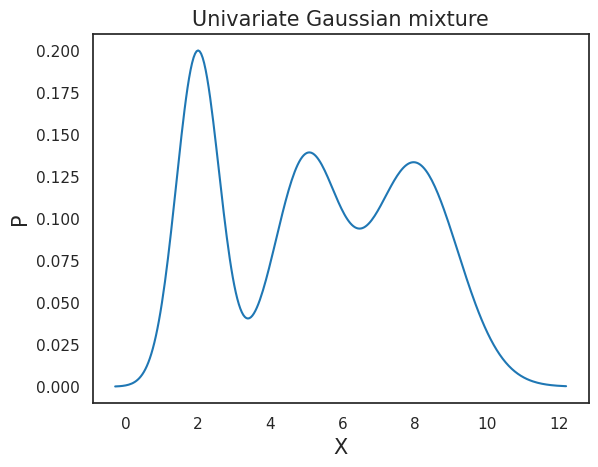

In [20]:
X2, fig2, ax2 = plot_univariate_mixture(
    means=[2, 5, 8], stds=[0.6, 0.9, 1.2], weights=[0.3, 0.3, 0.4]
)

Keeping the means and standard deviations unchanged, let's change the weights of the Gaussians and see how it affects the mixture's distribution.


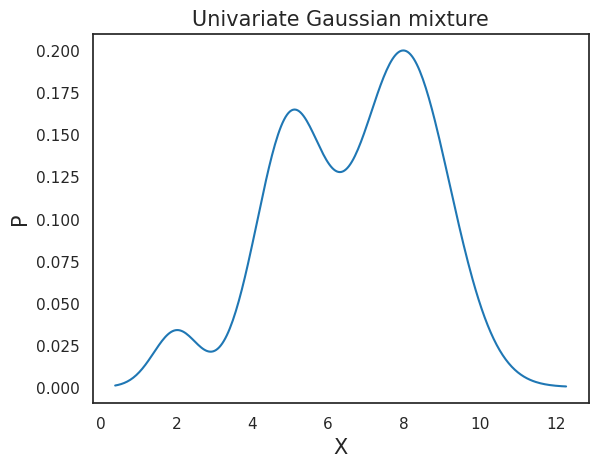

In [21]:
X3, fig3, ax3 = plot_univariate_mixture(
    means=[2, 5, 8], stds=[0.6, 0.9, 1.2], weights=[0.05, 0.35, 0.6]
)

When the weight of one Gaussian is reduced or increased, the likelihood of seeing a point from that Gaussian also decreases or increases, as illustrated in the distribution plot above.

Hence, in conclusion, the **means** determine the centers of the mixed Gaussians; the **covariance** matrices determine the width and shape of the mixed Gaussians; the **weights** determine the contributions of the Gaussians to the Gaussian mixture.


### **Introducing sklearn.mixture.GaussianMixture**


With artificially generated Gaussian mixture data, we already know the parameters of each Gaussian distribution, such as the means, variances, and weights. However, for real-world datasets, these values are usually unknown.

To estimate these parameters, we can use the **GaussianMixture** class from **Scikit-learn**. This class learns the Gaussian distributions directly from the data.

The `GaussianMixture.fit()` method trains the model and estimates:

- The number and locations of Gaussian distributions
- The variances of the distributions
- The probability that each data point belongs to each Gaussian

After training, the `GaussianMixture.predict()` method can assign each sample to the Gaussian distribution it most likely belongs to.

To estimate the parameters, GMM uses the **Expectation-Maximization (EM)** algorithm.

The EM algorithm works in two repeating steps:

1. **Expectation (E) step**  
   Estimate the probability that each data point belongs to each Gaussian distribution.

2. **Maximization (M) step**  
   Update the Gaussian parameters (means, variances, and weights) to better fit the data.

These two steps repeat until the model converges and the parameter values stop changing significantly.

For more detailed information about the EM algorithm, see:

<a href="https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01">EM Algorithm</a>

### **GMM.predict_proba**


The `GMM.predict_proba()` method calculates the probability that each data point belongs to each cluster.

For a sample $x_n$, the model estimates:

$$ p(i \mid x_n) $$

which represents the probability that sample $x_n$ belongs to cluster $i$.

One important parameter when using a GMM is `n_components`, which specifies the number of clusters (Gaussian distributions) the model should find in the dataset.

Another useful parameter is `covariance_type`, which controls the shape and flexibility of the clusters. For example, clusters can be circular, stretched, or tilted. We will discuss this later using multivariate datasets.

Using the univariate dataset **X1** generated earlier with `plot_univariate_mixture`, we can fit a GMM with `n_components = 3`.


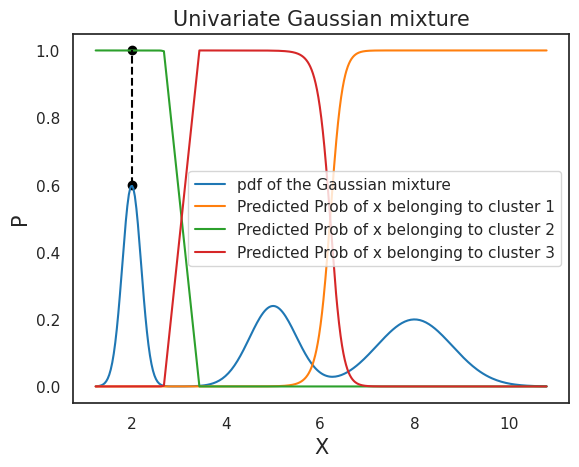

In [22]:
# sort X1 in ascending order for plotting purpose
X1_sorted = np.sort(X1.reshape(-1)).reshape(-1, 1)

# fit the GMM
GMM = GaussianMixture(n_components=3, random_state=10)
GMM.fit(X1_sorted)

# store the predicted probabilities in prob_X1
prob_X1 = GMM.predict_proba(X1_sorted)

# start plotting!
ax1.plot(
    X1_sorted, prob_X1[:, 0], label="Predicted Prob of x belonging to cluster 1"
)
ax1.plot(
    X1_sorted, prob_X1[:, 1], label="Predicted Prob of x belonging to cluster 2"
)
ax1.plot(
    X1_sorted, prob_X1[:, 2], label="Predicted Prob of x belonging to cluster 3"
)
ax1.scatter(2, 0.6, color="black")
ax1.scatter(2, 1.0, color="black")
ax1.plot([2, 2], [0.6, 1.0], "--", color="black")
ax1.legend()
fig1

The blue curve represents the overall Gaussian mixture distribution.

The other colored curves show the probability that a point \(x\) belongs to each cluster.

For example:

- Near \(x = 2\), the probability of belonging to cluster 2 is close to 1.
- Near \(x = 5\), the probability of belonging to cluster 3 is highest.
- Near \(x = 8\), the probability of belonging to cluster 1 is highest.

The dashed vertical line shows an example point, and the black dot shows its predicted cluster probability.

## **Example 1: Applying GMM on a 2d dataset**


### **Generate an artificial 2d Gaussian mixture data**


We will use the helper function **plot_bivariate_mixture** to first generate a 2d Gaussian mixture dataset, and then visualize the data points.


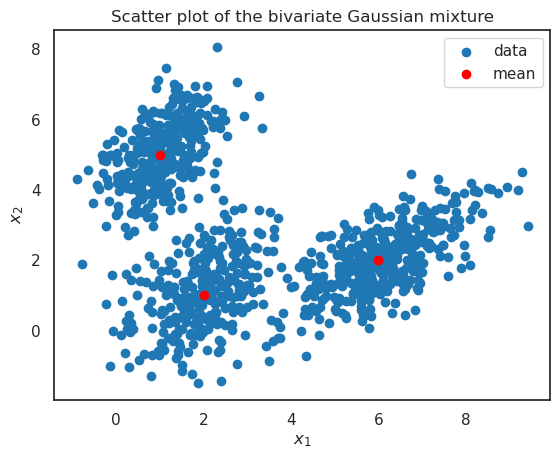

In [23]:
# setting parameter values for the Gaussian mixture data
# we include three Gaussians in this example

mean = [(1, 5), (2, 1), (6, 2)]
# cov1 = np.array([[0.5, 1.0], [1.0, 0.8]])
# cov2 = np.array([[0.8, 0.4], [0.4, 1.2]])
# cov3 = np.array([[1.2, 1.3], [1.3, 0.9]])
cov1 = np.array([[0.5, 0.3], [0.3, 0.8]])
cov2 = np.array([[0.8, 0.4], [0.4, 1.2]])
cov3 = np.array([[1.2, 0.7], [0.7, 0.9]])

cov = [cov1, cov2, cov3]
weights = [0.3, 0.3, 0.4]

X4 = plot_bivariate_mixture(means=mean, covs=cov, weights=weights, N=1000)

To work with GMM, we can use the **GaussianMixture** function from **sklearn.mixture**. The function will fit a GMM to our data and return the clustering result which includes the parameter values we discussed.


In [24]:
print("The dataset we generated has a shape of", X4.shape)

The dataset we generated has a shape of (1000, 2)


### **Fit a GMM**


In [25]:
# since we generated a mixture dataset X4 with 3 Gaussians, it makes sense to set n_components = 3.
gm = GaussianMixture(n_components=3, random_state=0).fit(X4)
print("Means of the 3 Gaussians fitted by GMM are\n")
print(gm.means_)

Means of the 3 Gaussians fitted by GMM are

[[1.03423474 5.03629519]
 [6.05715469 1.99726694]
 [1.95313231 1.0794582 ]]


In [26]:
print("Covariances of the 3 Gaussians fitted by GMM are")
gm.covariances_

Covariances of the 3 Gaussians fitted by GMM are


array([[[0.49707019, 0.35173974],
        [0.35173974, 0.92540028]],

       [[1.16588303, 0.69182945],
        [0.69182945, 0.9034886 ]],

       [[0.69622667, 0.38127782],
        [0.38127782, 1.14128572]]])

The 3 centers returned by our fitted GMM are all very close to the means we set for generating the mixture data, which means the model fitting was quite successful. 

We can also draw the 3 ellipses, using the fitted parameter values, to check if they indeed represent the 3 clusters from our generated data.


### **Plot the clusters**


We will use the helper functions **draw_ellipse** and **plot_gmm** to plot the original scatter plot as well as the clusters produced by a fitted GMM.


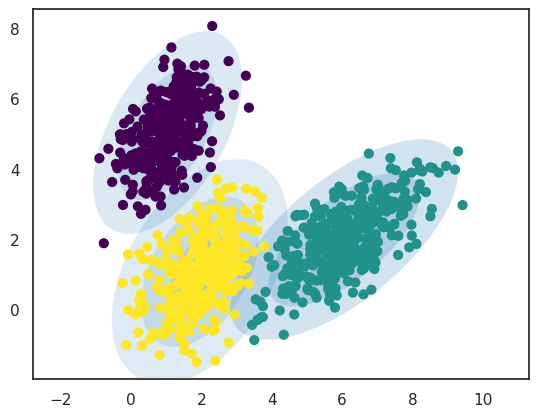

In [27]:
plot_gmm(
    GaussianMixture(n_components=3, random_state=0), X4  # the model,
)  # simulated Gaussian mixture data

### **Try different values of Covariance_type**


For `sklearn.mixture.GaussianMixture`, we can specify both the number of clusters and the cluster shapes using the `covariance_type` parameter.

The covariance matrix controls:

- the spread of the cluster along each axis
- the correlation between variables
- the rotation of the cluster

For example:

- Equal variances produce circular clusters.
- Different variances stretch the cluster.
- Nonzero covariance rotates the cluster into an ellipse.

Different datasets may have different cluster shapes, so GMM provides several covariance options:

- `full` – each cluster can have its own shape and orientation.
- `tied` – all clusters share the same shape.
- `diag` – clusters can stretch along each axis but cannot rotate.
- `spherical` – clusters are circular (or spherical in higher dimensions).

In general:

- `full` is the most flexible.
- `spherical` is the simplest.

_The default **Covariance_type** in **sklearn.mixture.GaussianMixture** is `full`._

**Sometimes you can't use covariance_type = full, because you can't invert it and this will give you an error.**


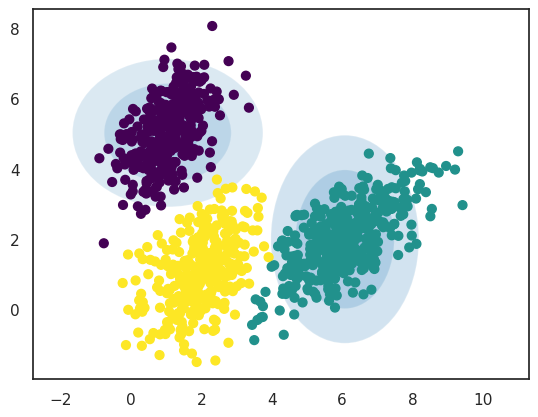

In [28]:
# try Covariance_type = 'tied'
plot_gmm(
    GaussianMixture(
        n_components=3, covariance_type="tied", random_state=0
    ),  # the model,
    X4,
)

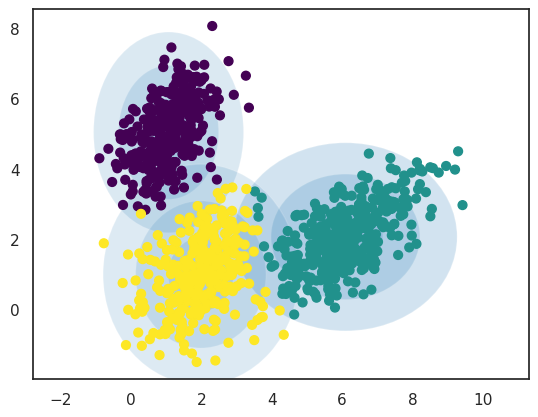

In [29]:
# try Covariance_type = 'diag'
plot_gmm(
    GaussianMixture(
        n_components=3, covariance_type="diag", random_state=0
    ),  # the model,
    X4,
)

It is clear visually that **covariance_type =** `full` is a good choice for the generated data. This makes sense because we did intentionally make each Gaussian have its own covariance matrix.

Now we know how to work with GMM in a lower dimension (2d), we can import a real-world dataset and use GMM to perform a clustering analysis on it.


## **Example 2: Applying GMM on real world data - Image Segmentation**


Image segmentation divides an image into multiple meaningful regions.

We can use GMM to group pixels with similar colors into \(K\) regions, where `n_components = K`.

In an RGB image, each pixel is treated as a data point with three features:

- red (R)
- green (G)
- blue (B)

For a grayscale image, each pixel has only one feature: brightness.

For example, a 256 × 256 image contains:

$256 \times 256 = 65536$  pixels.

Therefore, the dataset \(X\) would have shape:

$65536 \times 3$ for an RGB image.

Let's look at an example using a picture of a house cat:

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/images/gauss-cat.jpeg" style="width: 50%">


In [30]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/images/gauss-cat.jpeg"

img = np.asarray(Image.open(urlopen(url)).convert("RGB"))

# If img is greyscale, then change to .reshape(-1, 1):
X = img.reshape(-1, 3)
# The number of components; you can change this to a positive integer of your choice!:
n = 2
gmm = GaussianMixture(n_components=n, covariance_type="tied")
gmm.fit(X)
labels = gmm.predict(X)  # num of pixels x 1

Now, we replace each pixel with the "average color" or the mean RGB values of the gaussian distribution it belongs to:


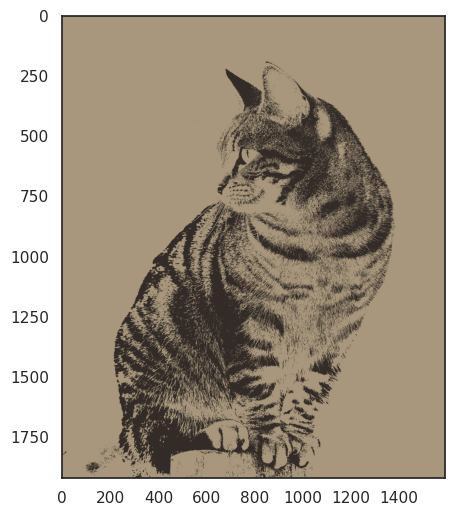

In [31]:
seg = np.zeros(X.shape)  # num of pixels x 3

for label in range(n):
    seg[labels == label] = gmm.means_[label]
seg = seg.reshape(img.shape).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(seg)

Similarly, if we increase the number of components to 8:


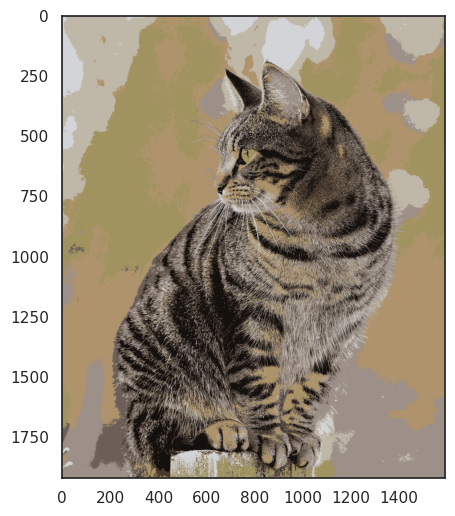

In [32]:
n = 8
gmm = GaussianMixture(n_components=n, covariance_type="tied")
gmm.fit(X)
labels = gmm.predict(X)  # num of pixels x 1
seg = np.zeros(X.shape)  # num of pixels x 3

for label in range(n):
    seg[labels == label] = gmm.means_[label]
seg = seg.reshape(img.shape).astype(np.uint8)
# cv2.imwrite(f'gauss-cat-{n}.jpeg', seg)

plt.figure(figsize=(6, 6))
plt.imshow(seg)
plt.show()

Our segmented image looks remarkably similar to the original, even though it uses only 8 colors!


## **Exercises**


For the exercises, we will use the Customer Personality Analysis dataset ([marketing_campaign.csv](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01)) from Kaggle, provided by Dr. Omar Romero-Hernandez. Several preprocessing steps were taken, including but not limited to, impute missing values, feature engineering, and feature encoding.

The preprocessed customers dataset contains 19 attributes on the customers' purchasing behaviors, education, income, marital status, etc. You will be able to practice principal component analysis, and apply GMM on the dataset for the purpose of customer segmentation.


First we load data into a `pandas.DataFrame`:


In [33]:
data = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/customers.csv"
)
data.head()

# you can also download the csv file to your local workspace using:
# ! wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/customers.csv

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Spent,Living_Status,Children
0,0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,1617,0,0
1,0,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,27,0,2
2,0,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,776,1,0
3,0,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,53,1,1
4,1,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,422,1,1


In [34]:
data.shape

(2216, 19)

### **Exercise 1 - Scale the data (using StandardScaler)**


In [35]:
from sklearn.preprocessing import StandardScaler

SS = StandardScaler()  # TODO
X = SS.fit_transform(X)  # TODO

### **Exercise 2 - Use PCA with n_components = 2 for dimension reduction**
PCA is used before GMM to reduce the number of features while preserving most of the important information in the data.

This helps:

- reduce noise
- simplify the clustering problem
- make visualization easier

In this exercise, PCA reduces the data to 2 dimensions so the GMM clusters can be plotted on a 2D graph.


In [36]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2)
reduced_2_PCA = pca2.fit_transform(X)

### **Exercise 3 - Fit a GMM to the reduced data**


In [37]:
model = GaussianMixture(n_components=4, random_state=0)
model.fit(reduced_2_PCA)

,n_components,4
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,0


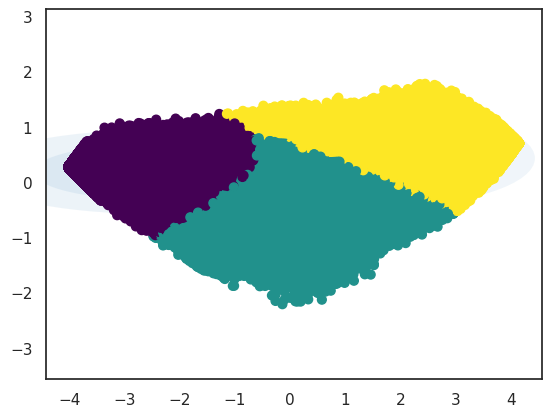

In [38]:
plot_gmm(
    GaussianMixture(
        n_components=3, covariance_type="diag", random_state=0
    ),  # the model,
    reduced_2_PCA,
)

### **Exercise 4 - Output the predicted labels for visualizing clusters**


In [39]:
PCA_2_pred = model.predict(reduced_2_PCA)

Now you can plot the clusters in 2d using 2 principal components, colored by predicted labels.


Text(0, 0.5, 'PCA 2')

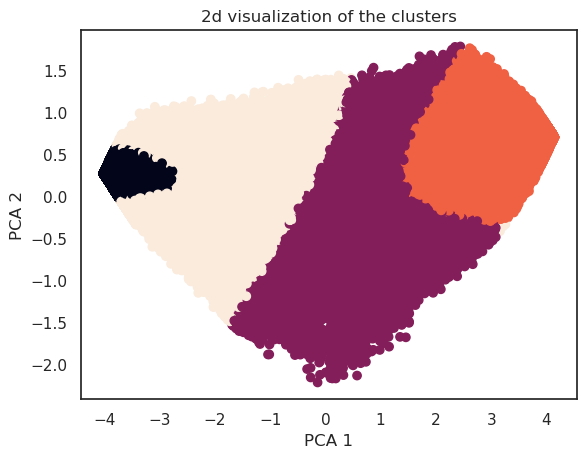

In [40]:
x = reduced_2_PCA[:, 0]
y = reduced_2_PCA[:, 1]
plt.scatter(x, y, c=PCA_2_pred)
plt.title("2d visualization of the clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

### **Exercise 5 - Clustering and visualizing using 3 principal components (OPTIONAL)**


Text(0.5, 0.92, '3D projection of the clusters')

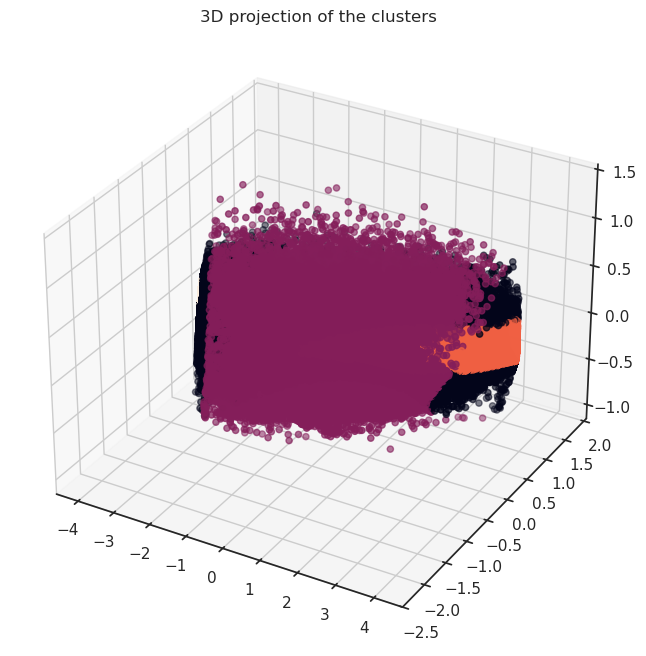

In [41]:
# use PCA with n=3 and implement GMM to make predictions

pca3 = PCA(n_components=3)
reduced_3_PCA = pca3.fit(X).transform(X)
mod = GaussianMixture(n_components=4, random_state=0)
PCA_3_pred = mod.fit(reduced_3_PCA).predict(reduced_3_PCA)

# plotting

reduced_3_PCA = pd.DataFrame(
    reduced_3_PCA, columns=(["PCA 1", "PCA 2", "PCA 3"])
)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    reduced_3_PCA["PCA 1"],
    reduced_3_PCA["PCA 2"],
    reduced_3_PCA["PCA 3"],
    c=PCA_3_pred,
)
ax.set_title("3D projection of the clusters")

## **Authors**


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.

Su Wu

## **Change Log**


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2020-07-17|0.1|Sam|Create Lab Template|
|2022-05-16|0.1|Roxanne|Create First Draft|
|2022-07-18|0.1|Svitlana K.|Review and Edit|
| 2026-05-10        | 0.2     | Su Wu       | Documentation and code edits|


Copyright © 2022 IBM Corporation. All rights reserved.
